<a href="https://colab.research.google.com/github/Amitabh-Phule/Reinforcement-Learning/blob/main/RL_Exp_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Title**
Dynamic Programming – Policy Evaluation

## **Aim**
To implement iterative policy evaluation for a Grid World environment using Dynamic Programming.

## **Theory**
Dynamic Programming (DP) is a method used in reinforcement learning to solve problems when the environment model is known.

Policy Evaluation is the process of calculating the value function for a given policy.

The value function V(s) represents the expected return obtained when the agent starts from state s and follows a particular policy.

For a state s, the Bellman expectation equation is:

V(s) = Σ π(a|s) Σ P(s'|s,a) [R(s,a,s') + γV(s')]

where:

V(s) = Value of current state
π(a|s) = Probability of selecting action a in state s
P(s'|s,a) = Probability of transitioning to next state s'
R(s,a,s') = Reward received
γ = Discount factor
V(s') = Value of the next state

In this experiment, a small Grid World environment is used.

The agent starts from different cells and follows a fixed policy. The value of each state is repeatedly updated until the values converge.

This process is called iterative policy evaluation.

## **Algorithm**

1. Create a Grid World environment.

2. Define all the states of the Grid World.

3. Define the possible actions:
   Up, Down, Left, and Right.

4. Define a fixed policy for the agent.

5. Initialize the value of every state to zero.

6. Select a state and calculate its expected value using the Bellman expectation equation.

7. Update the value of the state.

8. Repeat the process for all states.

9. Continue updating the values until the maximum change between two iterations becomes smaller than the specified threshold.

10. Display the final value function.

11. Visualize the state values using a Grid World plot.

## **Import Required Libraries**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## **Define Grid World**

In [2]:
## **Define Grid World**

grid_size = 4

# States are represented by their row and column positions
states = [(r, c) for r in range(grid_size) for c in range(grid_size)]

# Terminal states
terminal_states = [(0, 0), (3, 3)]

# Possible actions
actions = {
    "U": (-1, 0),
    "D": (1, 0),
    "L": (0, -1),
    "R": (0, 1)
}

print("Grid World Size:", grid_size, "x", grid_size)
print("Terminal States:", terminal_states)
print("Actions:", list(actions.keys()))

Grid World Size: 4 x 4
Terminal States: [(0, 0), (3, 3)]
Actions: ['U', 'D', 'L', 'R']


## **Define Fixed Policy**

In [3]:
## **Define Fixed Policy**

# Equal probability for all four actions
policy = {}

for state in states:
    if state in terminal_states:
        policy[state] = {}
    else:
        policy[state] = {
            "U": 0.25,
            "D": 0.25,
            "L": 0.25,
            "R": 0.25
        }

print("Policy defined successfully.")

for state in [(1, 1), (1, 2)]:
    print(state, policy[state])

Policy defined successfully.
(1, 1) {'U': 0.25, 'D': 0.25, 'L': 0.25, 'R': 0.25}
(1, 2) {'U': 0.25, 'D': 0.25, 'L': 0.25, 'R': 0.25}


## **Define Environment Transition**

In [4]:
## **Define Environment Transition**

def get_next_state(state, action):
    """Return next state after taking an action."""

    if state in terminal_states:
        return state

    row, col = state
    dr, dc = actions[action]

    new_row = row + dr
    new_col = col + dc

    # If the agent moves outside the grid,
    # it remains in the same state.
    if new_row < 0 or new_row >= grid_size:
        return state

    if new_col < 0 or new_col >= grid_size:
        return state

    return (new_row, new_col)


def get_reward(state, next_state):
    """Return reward for a transition."""

    if state in terminal_states:
        return 0

    return -1

## **Implement Iterative Policy Evaluation**

In [5]:
## **Implement Iterative Policy Evaluation**

gamma = 0.9
theta = 0.001

# Initialize value of all states to zero
V = {state: 0.0 for state in states}

iteration = 0

while True:

    delta = 0

    # Create a copy of current values
    new_V = V.copy()

    for state in states:

        # Terminal states have value 0
        if state in terminal_states:
            continue

        value = 0

        # Evaluate all possible actions
        for action, action_probability in policy[state].items():

            next_state = get_next_state(state, action)
            reward = get_reward(state, next_state)

            value += action_probability * (
                reward + gamma * V[next_state]
            )

        new_V[state] = value

        delta = max(delta, abs(value - V[state]))

    V = new_V
    iteration += 1

    if delta < theta:
        break

print("Policy evaluation completed.")
print("Number of iterations:", iteration)

Policy evaluation completed.
Number of iterations: 46


## **Display Final Value Function**

In [6]:
## **Display Final Value Function**

print("Final State Values:\n")

for row in range(grid_size):
    for col in range(grid_size):
        state = (row, col)
        print(f"{V[state]:8.3f}", end=" ")
    print()

Final State Values:

   0.000   -5.275   -7.124   -7.645 
  -5.275   -6.602   -7.176   -7.124 
  -7.124   -7.176   -6.602   -5.275 
  -7.645   -7.124   -5.275    0.000 


## **Visualize State Values**

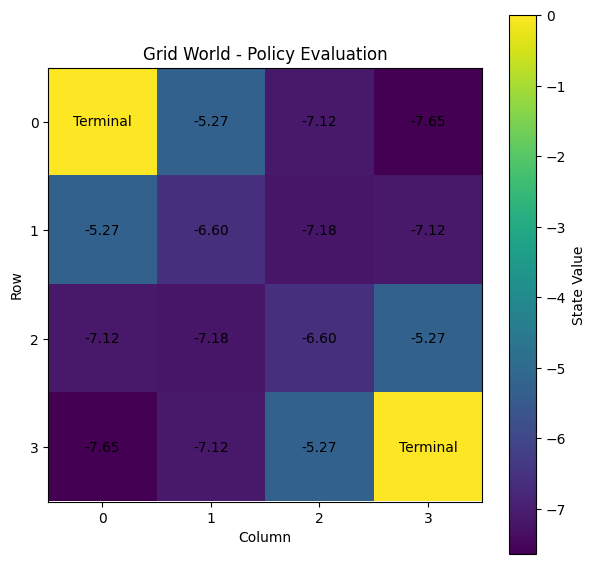

In [7]:
## **Visualize State Values**

value_grid = np.zeros((grid_size, grid_size))

for row in range(grid_size):
    for col in range(grid_size):
        value_grid[row, col] = V[(row, col)]

plt.figure(figsize=(7, 7))

plt.imshow(value_grid)

plt.colorbar(label="State Value")

plt.xticks(range(grid_size))
plt.yticks(range(grid_size))

plt.title("Grid World - Policy Evaluation")

# Display values inside cells
for row in range(grid_size):
    for col in range(grid_size):

        if (row, col) in terminal_states:
            text = "Terminal"
        else:
            text = f"{value_grid[row, col]:.2f}"

        plt.text(
            col,
            row,
            text,
            ha="center",
            va="center"
        )

plt.xlabel("Column")
plt.ylabel("Row")

plt.show()

## **Display Iteration Summary**

In [8]:
## **Display Iteration Summary**

print("========== POLICY EVALUATION SUMMARY ==========")
print("Grid Size:", f"{grid_size} x {grid_size}")
print("Discount Factor (gamma):", gamma)
print("Convergence Threshold (theta):", theta)
print("Iterations Required:", iteration)

print("\nFinal Value Function:")

for row in range(grid_size):
    values = []

    for col in range(grid_size):
        values.append(f"{V[(row, col)]:.2f}")

    print(" | ".join(values))

========== POLICY EVALUATION SUMMARY ==========
Grid Size: 4 x 4
Discount Factor (gamma): 0.9
Convergence Threshold (theta): 0.001
Iterations Required: 46

Final Value Function:
0.00 | -5.27 | -7.12 | -7.65
-5.27 | -6.60 | -7.18 | -7.12
-7.12 | -7.18 | -6.60 | -5.27
-7.65 | -7.12 | -5.27 | 0.00


## **Observation**

1. A 4 × 4 Grid World environment was created.

2. Two terminal states were defined.

3. A fixed policy with equal probability for all four actions was used.

4. Initially, the value of every state was set to zero.

5. The state values were repeatedly updated using the Bellman expectation equation.

6. The values gradually converged after multiple iterations.

7. States closer to the terminal states generally obtain better expected returns.

8. The final value function represents the expected return when the agent follows the given policy.

## **Conclusion**

Iterative Policy Evaluation was successfully implemented using Dynamic Programming on a Grid World environment.

The experiment demonstrated how the value function of a fixed policy can be calculated using the Bellman expectation equation.

The state values converged after repeated updates, showing how Dynamic Programming can be used to evaluate a policy when the environment model is known.